# 03. Combinatorial Epistasis & Genetic Synergy: Norman et al. 2019 (CRISPRa)

## Biological Background: Combinatorial Gene Interactions & Epistasis
Cellular phenotypes and cell-fate decisions are orchestrated by multi-component gene regulatory networks. While single-gene perturbations uncover individual gene functions, **combinatorial perturbations** are required to map **genetic interactions (GIs)** and epistasis:
- **Additive (Linear Independence)**: The effect of perturbing both genes simultaneously equals the sum of the individual effects:
  $$\Delta(A + B) \approx \Delta A + \Delta B$$
- **Synergy (Cooperation)**: The combination induces a response of greater magnitude or activates new transcriptional pathways not observed in either single perturbation:
  $$\|\Delta(A + B)\| \gg \|\Delta A + \Delta B\|$$
- **Buffering / Antagonism (Suppression)**: One gene overrides or blunts the response of the other, revealing hierarchical regulatory dominance:
  $$\Delta(A + B) \approx \Delta A \quad \text{or} \quad \|\Delta(A + B)\| \ll \|\Delta A + \Delta B\|$$

In their landmark study ([Norman et al., Science 365:786 (2019)](https://doi.org/10.1126/science.aax4438)), the authors pioneered dual-sgRNA **CRISPR activation (CRISPRa)** using dCas9-VPR in K562 erythroleukemia cells. They targeted key master transcription factors (e.g., `KLF1`, `SET`, `CEBPE`, `ETS2`, `FOXA3`, `OSR2`) controlling myeloid and erythroid cell-fate transitions.

```
                           ┌─────────────────────────────┐
                           │      Single Perturbations   │
                           │   Gene A (ΔA)   Gene B (ΔB) │
                           └──────────────┬──────────────┘
                                          │
                         ┌────────────────┴────────────────┐
                         ▼                                 ▼
             Additive Expectation                   Observed Combination
              Δ_add = ΔA + ΔB                       Δ_obs = x(A_B) - x_ctrl
                         │                                 │
                         └────────────────┬────────────────┘
                                          ▼
                               Interaction (Epistasis):
                               I = Δ_obs - (ΔA + ΔB)
```

---

### Objectives of this Notebook
1. Load `norman_2019_ready2train.h5ad` and catalog the single and dual perturbation landscape.
2. Confirm **on-target CRISPRa activation**: verify that target genes are specifically *overexpressed* relative to controls.
3. Quantify genetic epistasis by comparing the additive linear model ($\Delta A + \Delta B$) against actual observed combinatorial profiles ($\Delta_{AB}$).
4. Examine the challenge of **predicting unseen dual perturbations** (the GEARS benchmark).


In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import scipy.sparse as sp
import anndata as ad
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Helvetica, Arial, DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

DATA_FILE = Path("../data/norman_2019_ready2train.h5ad") if Path("../data").exists() else Path("data/norman_2019_ready2train.h5ad")
print("Loading:", DATA_FILE.resolve())


Loading: /Users/jubayer/Projects/perturb-bench/data/norman_2019_ready2train.h5ad


## 1. Loading Norman 2019 & Parsing Perturbation Types

In `norman_2019_ready2train.h5ad`, perturbations are either:
- **Control**: Non-targeting controls (`is_control == True`)
- **Single gene**: Single gene activation (e.g. `KLF1`, `SET`, `FOSB`)
- **Dual gene**: Two genes activated simultaneously, delimited by an underscore `_` (e.g. `SET_KLF1`, `KLF1_BAK1`)


In [2]:
adata = ad.read_h5ad(DATA_FILE)

# Identify controls and non-controls
ctrl_mask = adata.obs['is_control'].astype(bool)
all_perts = adata.obs.loc[~ctrl_mask, 'perturbation'].unique()

singles = [p for p in all_perts if '_' not in p]
doubles = [p for p in all_perts if '_' in p]

print(f"Total cells:          {adata.shape[0]:,}")
print(f"Transcriptome genes:  {adata.shape[1]:,}")
print(f"Control cells:        {ctrl_mask.sum():,} ({ctrl_mask.sum()/adata.shape[0]*100:.1f}%)")
print(f"Single perturbations: {len(singles):,}")
print(f"Double perturbations: {len(doubles):,}")
print(f"Total unique targets: {len(all_perts):,}")


Total cells:          111,445
Transcriptome genes:  33,694
Control cells:        11,855 (10.6%)
Single perturbations: 105
Double perturbations: 131
Total unique targets: 236


## 2. Representation Across Train / Val / Test Splits

The benchmark evaluates the model's ability to generalize to unseen perturbation combinations. Let's inspect how single and double perturbations are allocated across splits.


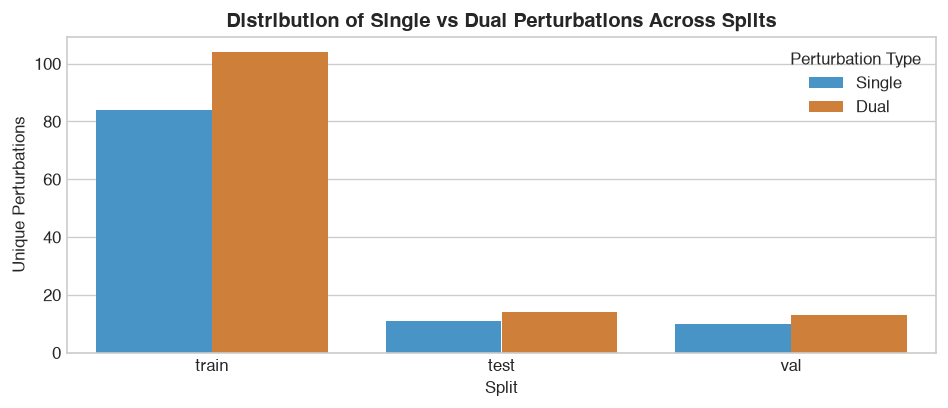

Split summary table:
Type   Dual  Single  All
Split                   
test     14      11   25
train   104      84  188
val      13      10   23
All     131     105  236


In [3]:
split_breakdown = []
for p in all_perts:
    p_type = 'Dual' if '_' in p else 'Single'
    split = adata.obs.loc[adata.obs['perturbation'] == p, 'split'].iloc[0]
    n_cells = (adata.obs['perturbation'] == p).sum()
    split_breakdown.append({'Perturbation': p, 'Type': p_type, 'Split': split, 'Cells': n_cells})

df_splits = pd.DataFrame(split_breakdown)

plt.figure(figsize=(8, 3.5))
sns.countplot(data=df_splits, x='Split', hue='Type', palette=['#3498db', '#e67e22'])
plt.title('Distribution of Single vs Dual Perturbations Across Splits', fontsize=12, fontweight='bold')
plt.xlabel('Split')
plt.ylabel('Unique Perturbations')
plt.legend(title='Perturbation Type')
plt.tight_layout()
plt.show()

print("Split summary table:")
print(pd.crosstab(df_splits['Split'], df_splits['Type'], margins=True))


## 3. Validating On-Target CRISPRa Overexpression

Unlike CRISPRi (which represses genes), CRISPRa recruits transcriptional machinery to promoter regions to **increase** expression.

Let's test whether single-gene perturbations result in marked upregulation of the corresponding endogenous gene compared to control cells.


In [4]:
ctrl_cells = adata[adata.obs['is_control']]
ctrl_X = ctrl_cells.X

test_tfs = ['KLF1', 'FOSB', 'FOXA3', 'CEBPE', 'OSR2', 'CBL']
activation_results = []

for tf in test_tfs:
    if tf not in adata.var_names or tf not in singles:
        continue
    g_idx = adata.var_names.get_loc(tf)
    
    # Control expression
    ctrl_exp = np.asarray(ctrl_X[:, g_idx].todense()).ravel()
    mean_ctrl = float(ctrl_exp.mean())
    
    # Perturbation expression
    pert_cells = adata[adata.obs['perturbation'] == tf]
    pert_exp = np.asarray(pert_cells.X[:, g_idx].todense()).ravel()
    mean_pert = float(pert_exp.mean())
    
    fold_increase = (mean_pert / mean_ctrl) if mean_ctrl > 0 else np.nan
    delta = mean_pert - mean_ctrl
    
    activation_results.append({
        'Target Gene': tf,
        'Ctrl Mean': round(mean_ctrl, 3),
        'Pert Mean': round(mean_pert, 3),
        'Delta (Shift)': round(delta, 3),
        'Fold Increase': round(fold_increase, 2),
        'Cells Profiled': len(pert_cells)
    })

df_act = pd.DataFrame(activation_results)
df_act


,Target Gene,Ctrl Mean,Pert Mean,Delta (Shift),Fold Increase,Cells Profiled
0,KLF1,0.410,1.162,0.752,2.83,1960
1,FOSB,0.005,0.046,0.041,9.72,630
2,FOXA3,0.038,0.287,0.249,7.57,494
3,CEBPE,0.023,1.461,1.437,62.72,1233
4,OSR2,0.039,0.589,0.550,14.98,1003
5,CBL,0.145,0.362,0.217,2.50,663


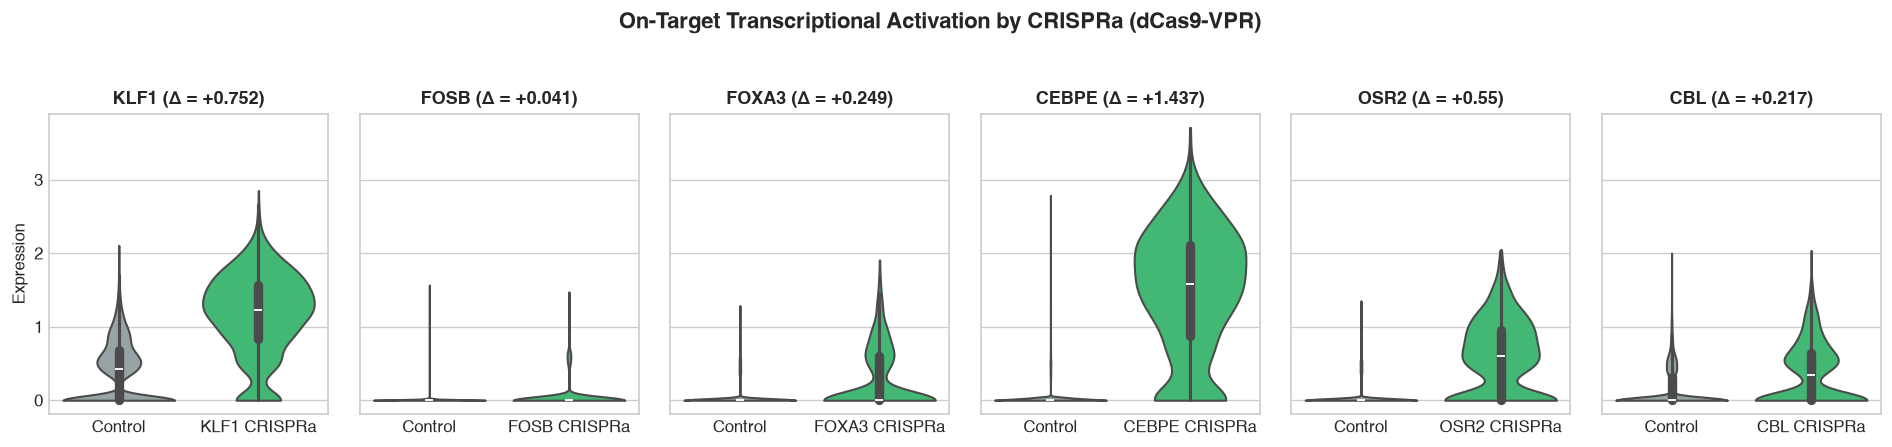

In [5]:
fig, axes = plt.subplots(1, len(df_act), figsize=(16, 3.5), sharey=True)

for i, row in df_act.iterrows():
    tf = row['Target Gene']
    g_idx = adata.var_names.get_loc(tf)
    
    c_vals = np.asarray(adata[adata.obs['is_control']].X[:, g_idx].todense()).ravel()
    p_vals = np.asarray(adata[adata.obs['perturbation'] == tf].X[:, g_idx].todense()).ravel()
    
    df_p = pd.DataFrame({
        'Expression': np.concatenate([c_vals, p_vals]),
        'Condition': ['Control'] * len(c_vals) + [f'{tf} CRISPRa'] * len(p_vals)
    })
    
    sns.violinplot(data=df_p, x='Condition', y='Expression', ax=axes[i], palette=['#95a5a6', '#2ecc71'], cut=0)
    axes[i].set_title(f"{tf} (Δ = +{row['Delta (Shift)']})", fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    if i > 0:
        axes[i].set_ylabel('')

plt.suptitle('On-Target Transcriptional Activation by CRISPRa (dCas9-VPR)', fontsize=13, y=1.05, fontweight='bold')
plt.tight_layout()
plt.show()


## 4. Modeling Genetic Interactions: Additive Model vs Observed Synergy

For a dual perturbation $A\_B$ where both single perturbations $A$ and $B$ are also measured:
1. **Observed Shift**: $\Delta_{AB} = \bar{x}_{AB} - \bar{x}_{\text{ctrl}}$
2. **Additive Prediction**: $\Delta_{\text{add}} = \Delta_A + \Delta_B$
3. **Epistatic Deviation**: $\mathcal{I}_{AB} = \Delta_{AB} - \Delta_{\text{add}}$

If $\mathcal{I}_{AB} \approx 0$, the genes act independently. If $\mathcal{I}_{AB}$ is large and non-zero, the genes interact synergistically or epistatically.


In [6]:
ctrl_mean_vec = np.asarray(adata[adata.obs['is_control']].X.mean(axis=0)).ravel()

def get_delta_vec(adata, pert_name, ctrl_mean):
    sub = adata[adata.obs['perturbation'] == pert_name]
    return np.asarray(sub.X.mean(axis=0)).ravel() - ctrl_mean

# Find dual perturbations where both single perturbations exist in the dataset
triplets = []
for p in doubles:
    g1, g2 = p.split('_')
    if g1 in singles and g2 in singles:
        triplets.append((g1, g2, p))

print(f"Total complete triplets (Gene A, Gene B, Gene A_B): {len(triplets)}")
print("Sample complete triplets:", triplets[:5])


Total complete triplets (Gene A, Gene B, Gene A_B): 131
Sample complete triplets: [('SET', 'KLF1', 'SET_KLF1'), ('KLF1', 'BAK1', 'KLF1_BAK1'), ('FOXA3', 'FOXL2', 'FOXA3_FOXL2'), ('IRF1', 'SET', 'IRF1_SET'), ('IGDCC3', 'MAPK1', 'IGDCC3_MAPK1')]


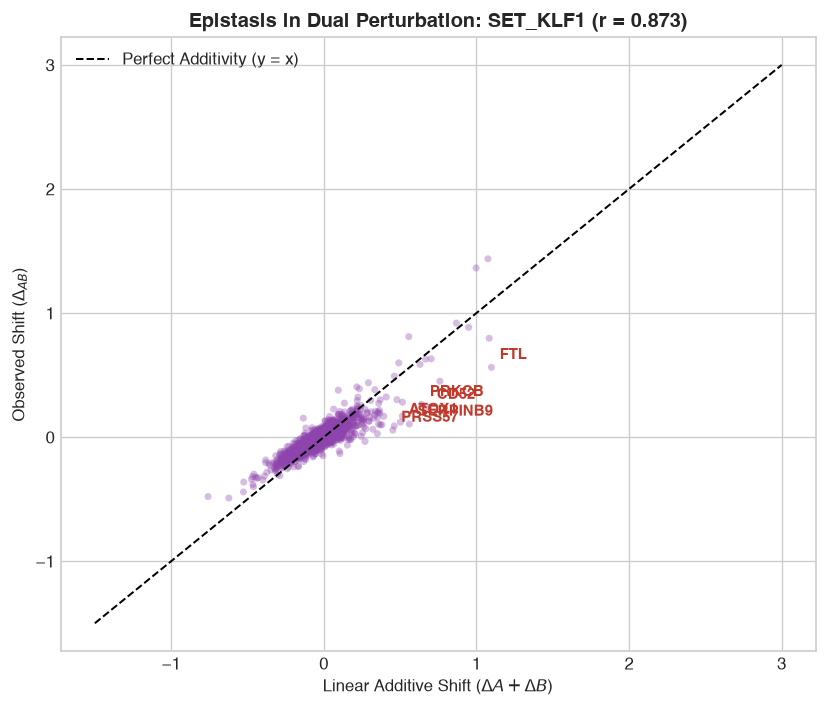

In [7]:
# Case study: KLF1 and SET interaction (erythroid master regulator KLF1)
case_g1, case_g2, case_pair = 'SET', 'KLF1', 'SET_KLF1'

delta_A = get_delta_vec(adata, case_g1, ctrl_mean_vec)
delta_B = get_delta_vec(adata, case_g2, ctrl_mean_vec)
delta_pair = get_delta_vec(adata, case_pair, ctrl_mean_vec)
delta_add = delta_A + delta_B
epistasis = delta_pair - delta_add

# Scatter plot: Additive Expectation vs Observed Combination
plt.figure(figsize=(7, 6))
plt.scatter(delta_add, delta_pair, alpha=0.35, color='#8e44ad', edgecolors='none', s=18)
plt.plot([-1.5, 3], [-1.5, 3], color='black', linestyle='--', linewidth=1.2, label='Perfect Additivity (y = x)')

# Highlight top epistatic genes
epistasis_abs = np.abs(epistasis)
top_epistatic_idx = np.argsort(epistasis_abs)[::-1][:6]
for idx in top_epistatic_idx:
    gene = adata.var_names[idx]
    plt.annotate(
        gene, 
        (delta_add[idx], delta_pair[idx]),
        fontsize=9, fontweight='bold', color='#c0392b',
        xytext=(5, 5), textcoords='offset points'
    )

corr_add = np.corrcoef(delta_add, delta_pair)[0, 1]
plt.title(f'Epistasis in Dual Perturbation: {case_pair} (r = {corr_add:.3f})', fontsize=12, fontweight='bold')
plt.xlabel(r'Linear Additive Shift ($\Delta A + \Delta B$)')
plt.ylabel(r'Observed Shift ($\Delta_{AB}$)')
plt.legend()
plt.tight_layout()
plt.show()


## 5. Global Landscape of Genetic Interactions

We compute the correlation between the linear additive expectation and the observed dual perturbation across all available pairs.


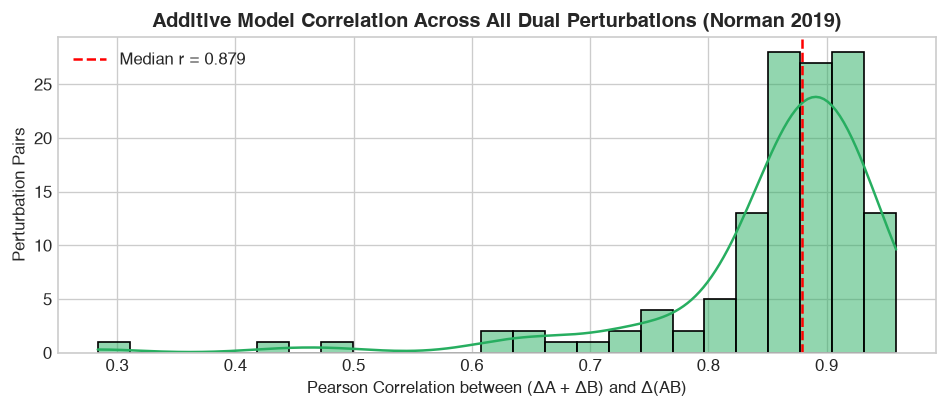

In [8]:
corrs = []
for g1, g2, pair in triplets:
    d1 = get_delta_vec(adata, g1, ctrl_mean_vec)
    d2 = get_delta_vec(adata, g2, ctrl_mean_vec)
    d_pair = get_delta_vec(adata, pair, ctrl_mean_vec)
    d_add = d1 + d2
    r = float(np.corrcoef(d_add, d_pair)[0, 1])
    corrs.append({'Pair': pair, 'Additive_r': r})

df_corrs = pd.DataFrame(corrs)

plt.figure(figsize=(8, 3.5))
sns.histplot(df_corrs['Additive_r'], bins=25, color='#27ae60', kde=True)
plt.axvline(df_corrs['Additive_r'].median(), color='red', linestyle='--', 
            label=f"Median r = {df_corrs['Additive_r'].median():.3f}")
plt.title('Additive Model Correlation Across All Dual Perturbations (Norman 2019)', fontsize=12, fontweight='bold')
plt.xlabel('Pearson Correlation between (ΔA + ΔB) and Δ(AB)')
plt.ylabel('Perturbation Pairs')
plt.legend()
plt.tight_layout()
plt.show()


## Summary & Modeling Takeaways

1. **CRISPRa Induces Strong Expression Shifts**: On-target transcription factors are overexpressed multiple-fold over control baselines.
2. **The Additive Linear Baseline is Strong but Incomplete**: While the median correlation of the additive sum ($\Delta A + \Delta B$) to the observed response is $\sim 0.70 - 0.85$, a significant fraction of pairs exhibit marked non-linear synergy or buffering.
3. **Benchmark Importance for Deep Learning**: Machine learning models like GEARS (*Roohani et al. 2023*) specifically use gene co-expression and knowledge graphs to model these non-linear interaction terms.
